In [28]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🚀 HelpDesk AI - Data Loading Started")

🚀 HelpDesk AI - Data Loading Started


In [29]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(DATA_DIR)

d:\Development\helpdesk-ai\data\raw


In [30]:
for file in DATA_DIR.iterdir():
    print(file.name)

.DS_Store
movie_characters_metadata.txt
movie_conversations.txt
movie_lines.txt
movie_titles_metadata.txt
raw_script_urls.txt
README.txt


In [31]:
def load_movie_lines(filepath):
    """
    Load movie lines from the Cornell Movie Dialogs Corpus.

    Returns:
        dict
    """

    movie_lines = {}

    with open(filepath,
              encoding="iso-8859-1") as f:

        for line in f:

            parts = line.strip().split(" +++$+++ ")

            if len(parts) == 5:

                line_id = parts[0]

                movie_lines[line_id] = {
                    "character": parts[3],
                    "text": parts[4]
                }

    return movie_lines

In [32]:
movie_lines = load_movie_lines(
    DATA_DIR / "movie_lines.txt"
)

print("Total Movie Lines:", len(movie_lines))

list(movie_lines.items())[:5]

Total Movie Lines: 304446


[('L1045', {'character': 'BIANCA', 'text': 'They do not!'}),
 ('L1044', {'character': 'CAMERON', 'text': 'They do to!'}),
 ('L985', {'character': 'BIANCA', 'text': 'I hope so.'}),
 ('L984', {'character': 'CAMERON', 'text': 'She okay?'}),
 ('L925', {'character': 'BIANCA', 'text': "Let's go."})]

In [33]:
def load_conversations(filepath):
    """
    Load movie conversations from the Cornell Movie Dialogs Corpus.

    Returns:
        list
    """

    conversations = []

    with open(filepath, encoding="iso-8859-1") as f:

        for line in f:

            parts = line.strip().split(" +++$+++ ")

            if len(parts) == 4:

                conversation = parts[3]

                conversation = (
                    conversation
                    .replace("[", "")
                    .replace("]", "")
                    .replace("'", "")
                    .replace(",", "")
                )

                line_ids = conversation.split()

                conversations.append(line_ids)

    return conversations

In [34]:
conversations = load_conversations(
    DATA_DIR / "movie_conversations.txt"
)

print("Total Conversations:", len(conversations))

conversations[:5]

Total Conversations: 83097


[['L194', 'L195', 'L196', 'L197'],
 ['L198', 'L199'],
 ['L200', 'L201', 'L202', 'L203'],
 ['L204', 'L205', 'L206'],
 ['L207', 'L208']]

In [35]:
question_answer_pairs = []

for conversation in conversations:

    for i in range(len(conversation) - 1):

        question_id = conversation[i]
        answer_id = conversation[i + 1]

        if question_id in movie_lines and answer_id in movie_lines:

            question = movie_lines[question_id]["text"].strip()
            answer = movie_lines[answer_id]["text"].strip()

            if question and answer:

                question_answer_pairs.append((question, answer))

print("Total QA Pairs:", len(question_answer_pairs))

Total QA Pairs: 221282


In [36]:
question_answer_pairs[:10]

[('Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.',
  "Well, I thought we'd start with pronunciation, if that's okay with you."),
 ("Well, I thought we'd start with pronunciation, if that's okay with you.",
  'Not the hacking and gagging and spitting part.  Please.'),
 ('Not the hacking and gagging and spitting part.  Please.',
  "Okay... then how 'bout we try out some French cuisine.  Saturday?  Night?"),
 ("You're asking me out.  That's so cute. What's your name again?",
  'Forget it.'),
 ("No, no, it's my fault -- we didn't have a proper introduction ---",
  'Cameron.'),
 ('Cameron.',
  "The thing is, Cameron -- I'm at the mercy of a particularly hideous breed of loser.  My sister.  I can't date until she does."),
 ("The thing is, Cameron -- I'm at the mercy of a particularly hideous breed of loser.  My sister.  I can't date until she does.",
  'Seems like she could get a date easy enough...'),
 (

In [37]:
def clean_text(text):
    """
    Clean and normalize text for chatbot training.
    """

    text = text.lower()

    # Expand contractions
    contractions = {
        "i'm": "i am",
        "he's": "he is",
        "she's": "she is",
        "it's": "it is",
        "that's": "that is",
        "what's": "what is",
        "where's": "where is",
        "how's": "how is",
        "'ll": " will",
        "'ve": " have",
        "'re": " are",
        "'d": " would",
        "won't": "will not",
        "can't": "cannot",
        "n't": " not"
    }

    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # Remove unwanted characters
    text = re.sub(r"[^a-zA-Z0-9?.!, ]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [38]:
question_answer_pairs = []

for conversation in conversations:

    for i in range(len(conversation) - 1):

        question_id = conversation[i]
        answer_id = conversation[i + 1]

        if question_id in movie_lines and answer_id in movie_lines:

            question = movie_lines[question_id]["text"].strip()
            answer = movie_lines[answer_id]["text"].strip()

            if question and answer:
                question_answer_pairs.append((question, answer))

print("Total QA Pairs:", len(question_answer_pairs))

Total QA Pairs: 221282


In [39]:
clean_questions = []
clean_answers = []

for q, a in question_answer_pairs:

    q = clean_text(q)
    a = clean_text(a)

    if len(q.split()) >= 2 and len(a.split()) >= 2:

        clean_questions.append(q)
        clean_answers.append(a)

print("Questions:", len(clean_questions))
print("Answers:", len(clean_answers))

Questions: 190101
Answers: 190101


In [40]:
for i in range(10):

    print("Q:", clean_questions[i])
    print("A:", clean_answers[i])
    print("-"*60)

Q: can we make this quick? roxanne korrine and andrew barrett are having an incredibly horrendous public break up on the quad. again.
A: well, i thought we would start with pronunciation, if that is okay with you.
------------------------------------------------------------
Q: well, i thought we would start with pronunciation, if that is okay with you.
A: not the hacking and gagging and spitting part. please.
------------------------------------------------------------
Q: not the hacking and gagging and spitting part. please.
A: okay... then how bout we try out some french cuisine. saturday? night?
------------------------------------------------------------
Q: you are asking me out. that is so cute. what is your name again?
A: forget it.
------------------------------------------------------------
Q: the thing is, cameron i am at the mercy of a particularly hideous breed of loser. my sister. i cannot date until she does.
A: seems like she could get a date easy enough...
--------------

In [41]:
question_lengths = [len(q.split()) for q in clean_questions]
answer_lengths = [len(a.split()) for a in clean_answers]

print("Question Statistics")
print("-------------------")
print("Minimum:", min(question_lengths))
print("Maximum:", max(question_lengths))
print("Average:", round(sum(question_lengths)/len(question_lengths),2))

print()

print("Answer Statistics")
print("----------------")
print("Minimum:", min(answer_lengths))
print("Maximum:", max(answer_lengths))
print("Average:", round(sum(answer_lengths)/len(answer_lengths),2))

Question Statistics
-------------------
Minimum: 2
Maximum: 319
Average: 11.73

Answer Statistics
----------------
Minimum: 2
Maximum: 502
Average: 12.11


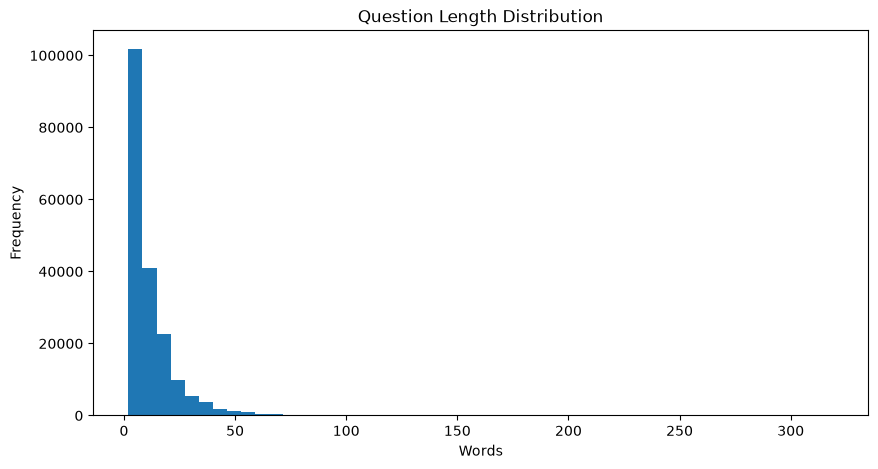

In [42]:
plt.figure(figsize=(10,5))

plt.hist(question_lengths, bins=50)

plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [43]:
MAX_LENGTH = 20

filtered_questions = []
filtered_answers = []

for q, a in zip(clean_questions, clean_answers):

    if len(q.split()) <= MAX_LENGTH and len(a.split()) <= MAX_LENGTH:

        filtered_questions.append(q)
        filtered_answers.append(a)

print("Filtered Questions:", len(filtered_questions))
print("Filtered Answers:", len(filtered_answers))

Filtered Questions: 138230
Filtered Answers: 138230


In [44]:
filtered_answers = [
    "<SOS> " + answer + " <EOS>"
    for answer in filtered_answers
]

In [45]:
for i in range(5):

    print("Q:", filtered_questions[i])
    print("A:", filtered_answers[i])
    print("-"*60)

Q: well, i thought we would start with pronunciation, if that is okay with you.
A: <SOS> not the hacking and gagging and spitting part. please. <EOS>
------------------------------------------------------------
Q: not the hacking and gagging and spitting part. please.
A: <SOS> okay... then how bout we try out some french cuisine. saturday? night? <EOS>
------------------------------------------------------------
Q: you are asking me out. that is so cute. what is your name again?
A: <SOS> forget it. <EOS>
------------------------------------------------------------
Q: gosh, if only we could find kat a boyfriend...
A: <SOS> let me see what i can do. <EOS>
------------------------------------------------------------
Q: c esc ma tete. this is my head
A: <SOS> right. see? you are ready for the quiz. <EOS>
------------------------------------------------------------


In [46]:
dataset = pd.DataFrame({
    "question": filtered_questions,
    "answer": filtered_answers
})

dataset.head()

,question,answer
0,"well, i thought we would start with pronunciat...",<SOS> not the hacking and gagging and spitting...
1,not the hacking and gagging and spitting part....,<SOS> okay... then how bout we try out some fr...
2,you are asking me out. that is so cute. what i...,<SOS> forget it. <EOS>
3,"gosh, if only we could find kat a boyfriend...",<SOS> let me see what i can do. <EOS>
4,c esc ma tete. this is my head,<SOS> right. see? you are ready for the quiz. ...


In [47]:
dataset.to_csv(
    PROJECT_ROOT / "data" / "processed" / "chat_dataset.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [48]:
pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "chat_dataset.csv"
).head()

,question,answer
0,"well, i thought we would start with pronunciat...",<SOS> not the hacking and gagging and spitting...
1,not the hacking and gagging and spitting part....,<SOS> okay... then how bout we try out some fr...
2,you are asking me out. that is so cute. what i...,<SOS> forget it. <EOS>
3,"gosh, if only we could find kat a boyfriend...",<SOS> let me see what i can do. <EOS>
4,c esc ma tete. this is my head,<SOS> right. see? you are ready for the quiz. ...


In [49]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [50]:
VOCAB_SIZE = 15000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    filters="",
    oov_token="<UNK>"
)

In [51]:
tokenizer.fit_on_texts(
    filtered_questions +
    filtered_answers
)

In [52]:
word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 77160


In [53]:
list(word_index.items())[:30]

[('<UNK>', 1),
 ('<sos>', 2),
 ('<eos>', 3),
 ('i', 4),
 ('you', 5),
 ('the', 6),
 ('is', 7),
 ('to', 8),
 ('not', 9),
 ('a', 10),
 ('do', 11),
 ('it', 12),
 ('are', 13),
 ('what', 14),
 ('that', 15),
 ('have', 16),
 ('of', 17),
 ('and', 18),
 ('we', 19),
 ('am', 20),
 ('in', 21),
 ('he', 22),
 ('will', 23),
 ('your', 24),
 ('s', 25),
 ('for', 26),
 ('my', 27),
 ('was', 28),
 ('this', 29),
 ('me', 30)]